## Install

In [7]:
!pip install -q transformers peft trl bitsandbytes accelerate datasets

## Imports

In [8]:

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset

## Model Name

In [9]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

## 4-Bit Config

In [10]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

## Tokenizer

In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
tokenizer.model_max_length = 512

## Load Model

In [12]:
from peft import prepare_model_for_kbit_training
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

## Lora Configs

In [13]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)


model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


## Dataset

In [15]:
dataset = load_dataset("json", data_files="train.jsonl")
dataset = dataset["train"]

# print(dataset)

def format_prompt(sample):
    text = f"### Task Type: {sample['type']}\n\n"
    text += f"### Instruction:\n{sample['instruction']}\n\n"

    if sample["input"].strip():
        text += f"### Input:\n{sample['input']}\n\n"

    text += f"### Response:\n{sample['output']}"

    return {"text": text}


dataset = dataset.map(
    format_prompt,
    remove_columns=dataset.column_names
)

val_dataset = load_dataset("json", data_files="val.jsonl", split="train")
val_dataset = val_dataset.map(
    format_prompt,
    remove_columns=val_dataset.column_names
    )

print(val_dataset[0])
print(val_dataset.column_names)

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1017 [00:00<?, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/114 [00:00<?, ? examples/s]

{'text': '### Task Type: extraction\n\n### Instruction:\nIdentify the type of the following variables in C++\n\n### Input:\nint a;\nchar b;\nfloat c;\n\n### Response:\na is an integer, \nb is a character, \nc is a floating point number.'}
['text']


## The Actual Training

In [16]:

args = SFTConfig(
    output_dir="./adapters",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    learning_rate=2e-4,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    save_steps=50,
    logging_steps=10,
    report_to="none",
    dataset_text_field="text",
    eval_strategy="steps",
    eval_steps=50,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    eval_dataset=val_dataset,
    args=args,
    processing_class=tokenizer,
)

trainer.train()

Adding EOS to train dataset:   0%|          | 0/1017 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1017 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/114 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/114 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss,Validation Loss
50,0.842099,0.888492
100,0.811811,0.866879
150,0.796111,0.860755
200,0.805876,0.847903
250,0.766358,0.844788
300,0.711280,0.845960
350,0.855858,0.843605
400,0.706873,0.843688
450,0.694858,0.843723
500,0.866084,0.840552


TrainOutput(global_step=765, training_loss=0.7594993139404097, metrics={'train_runtime': 2321.7029, 'train_samples_per_second': 1.314, 'train_steps_per_second': 0.329, 'total_flos': 3344630061035520.0, 'train_loss': 0.7594993139404097})

## Save Adapters

In [17]:
trainer.model.save_pretrained("./adapters/")
tokenizer.save_pretrained("./adapters/")

print("Training done! Adapter saved to ./adapters/")

Training done! Adapter saved to ./adapters/


## Plot of loss

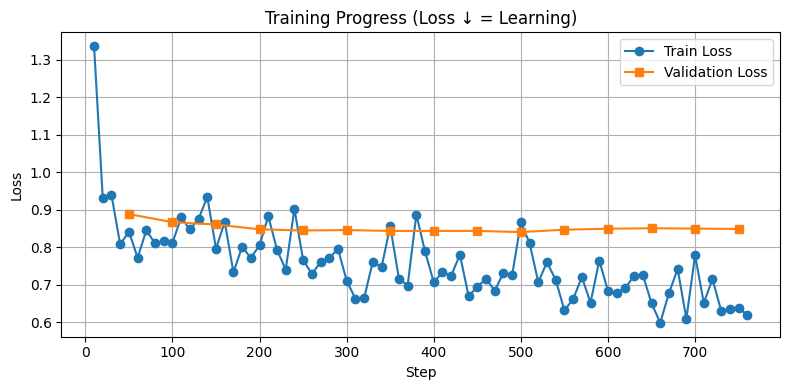

Train Loss: 1.3356 → 0.6199
Eval Loss: 0.8885 → 0.8488


In [18]:
import matplotlib.pyplot as plt


train_logs = [log for log in trainer.state.log_history if "loss" in log and "eval_loss" not in log]
train_steps = [log["step"] for log in train_logs]
train_loss = [log["loss"] for log in train_logs]


eval_logs = [log for log in trainer.state.log_history if "eval_loss" in log]
eval_steps = [log["step"] for log in eval_logs]
eval_loss = [log["eval_loss"] for log in eval_logs]

plt.figure(figsize=(8, 4))

plt.plot(train_steps, train_loss, marker="o", label="Train Loss")
if eval_loss:
    plt.plot(eval_steps, eval_loss, marker="s", label="Validation Loss")

plt.title("Training Progress (Loss ↓ = Learning)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("loss_curve.png")
plt.show()


if train_loss:
    print("Train Loss:", round(train_loss[0], 4), "→", round(train_loss[-1], 4))

if eval_loss:
    print("Eval Loss:", round(eval_loss[0], 4), "→", round(eval_loss[-1], 4))